# Solver Westervelt: test inspiré de Nikolić-Wohlmuth

Ce notebook présente un test 1D du modèle de Westervelt avec les paramètres physiques utilisés dans l'expérience numérique de Nikolić-Wohlmuth :
- milieu : eau,
- données initiales gaussiennes,
- temps final $T=37\,\mu s$,
- $2001$ points en temps, donc $2000$ pas de temps.

Le notebook permet aussi de visualiser les snapshots, l'énergie discrète et une mini étude de stabilité numérique.


## Équation continue et schémas discrets

On considère :
$$
(1-2ku)u_{tt} - c^2 u_{xx} - b u_{xxt} = 2k(u_t)^2.
$$

Variable auxiliaire :
$$
F(u) = (1-2ku)u_t - b u_{xx}.
$$

Alors :
$$
\partial_t F(u) - c^2 u_{xx} = 0.
$$

Dans le code, on utilise une mise à jour explicite ou semi-implicite basée sur cette variable auxiliaire. Le point important pour ce notebook est que l'initialisation respecte maintenant les deux données de Cauchy :
$$
u(0,x)=u_0(x), \qquad u_t(0,x)=u_1(x).
$$

Pour assurer la cohérence avec $u_t(0,x)=u_1(x)$, on reconstruit :
$$
u^{-1}=u^0-\Delta t\,u_1.
$$


In [1]:
from core.solver import WesterveltSolver, WesterveltParams
from core.postprocessing import plot_stability_scan
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

## Configuration de la simulation : paramètres de Nikolić--Wohlmuth

On utilise :

$$
c=1500\,m/s,\qquad \rho_0=1000\,kg/m^3,\qquad b=6 \times 10^{-9}\,m^2/s,\qquad \beta_a=3.5.
$$

Les données initiales sont :

$$
u_0(x)=A_1\exp\left(-\frac{(x-\mu)^2}{2\sigma_1^2}\right),
$$

$$
u_1(x)=A_2(x-\mu)\exp\left(-\frac{(x-\mu)^2}{2\sigma_2^2}\right),
$$

avec :

$$
A_1=1.2	\times 10^8,\quad A_2=-10^{11},\quad \sigma_1=0.015,\quad \sigma_2=0.02,\quad \mu=0.1.
$$


In [2]:
# Paramètres physiques et numériques inspirés de Nikolić--Wohlmuth
T_final = 37e-6
nt = 2000                  # 2001 points en temps, donc 2000 pas
L = 0.2
nx = 2000                  # domaine [0, 0.2] avec dx = 1e-4

dx = L / nx
dt = T_final / nt

params = WesterveltParams(
    c=1500.0,
    rho0=1000.0,
    beta=3.5,
    mu_v=6e-6,             # donne b = mu_v / rho0 = 6e-9 m^2/s
    dx=dx,
    dt=dt,
    nx=nx,
    nt=nt,
    scheme="explicit",
    bc="dirichlet",
)

solver = WesterveltSolver(params)

solver.initialize(
    u0_type="gaussian",
    u1_type="gaussian_derivative",
    A1=1.2e8,
    A2=1.0e11,
    mu=0.1,
    sigma1=0.015,
    sigma2=0.02,
)

print(f"dx = {params.dx:.3e} m")
print(f"dt = {params.dt:.3e} s")
print(f"T  = {params.nt * params.dt:.3e} s")
print(f"b  = {params.b:.3e} m^2/s")
print(f"k  = {params.k:.3e} Pa^-1")
print(f"1/(2k) = {1.0 / (2.0 * params.k):.3e} Pa")
print(f"max(u0) = {solver.u.max():.3e} Pa")
print(f"min(1 - 2ku0) = {(1.0 - 2.0 * params.k * solver.u).min():.6f}")


Indicateurs: CFL=0.2775, lambda=4.1625e+06 (legacy)
Marge de stabilité explicite: 9.22994e-09
Stable (marge positive)
dx = 1.000e-04 m
dt = 1.850e-08 s
T  = 3.700e-05 s
b  = 6.000e-09 m^2/s
k  = 1.556e-09 Pa^-1
1/(2k) = 3.214e+08 Pa
max(u0) = 1.200e+08 Pa
min(1 - 2ku0) = 0.626667


## Snapshots de la solution


[PROFILE] run_with_snapshots | temps: 0.4261s | pic mémoire: 0.31 MB

Résumé du profiling
------------------------------------------------------------
run_with_snapshots
  appels          : 1
  temps total     : 0.4261 s
  temps moyen     : 0.4261 s
  temps max       : 0.4261 s
  mémoire max     : 0.3101 MB



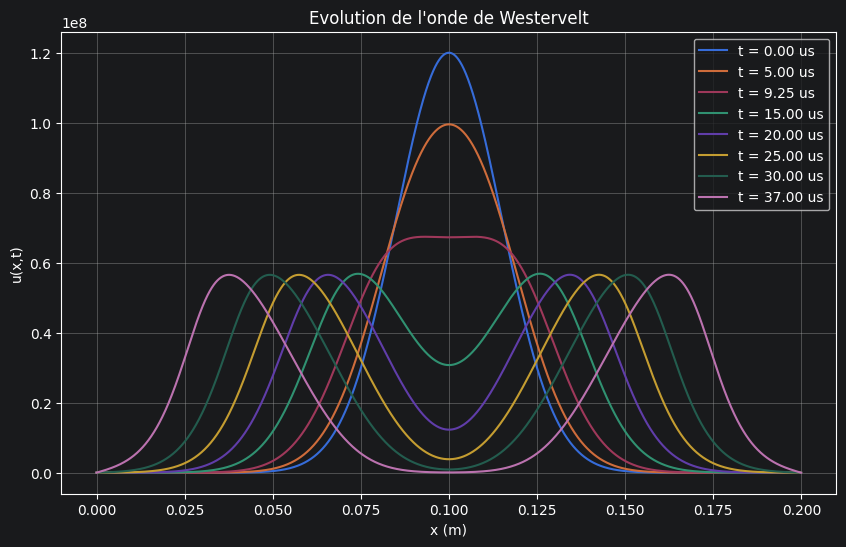

In [3]:
times = [0.0, 5e-6, 9.25e-6, 15e-6, 20e-6, 25e-6, 30e-6, 37e-6]
snapshots = solver.run_with_snapshots(times, store_energy=True)
solver.print_profiler_summary()
solver.plot_snapshots(snapshots)


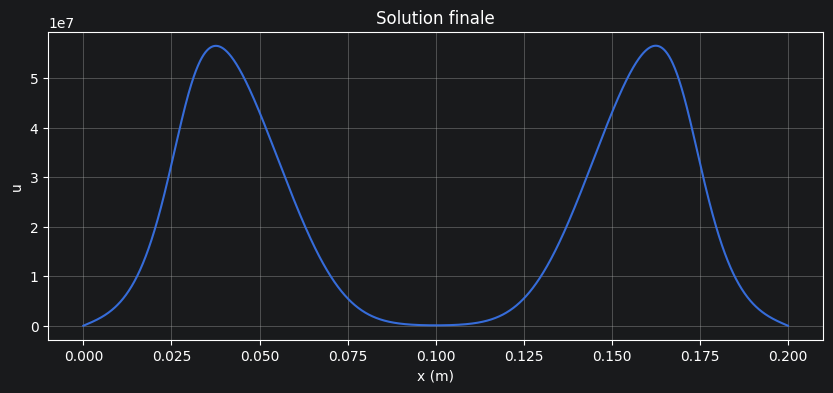

In [4]:
# Solution finale à T_final
solver.plot_solution()

## Graphe d'energie


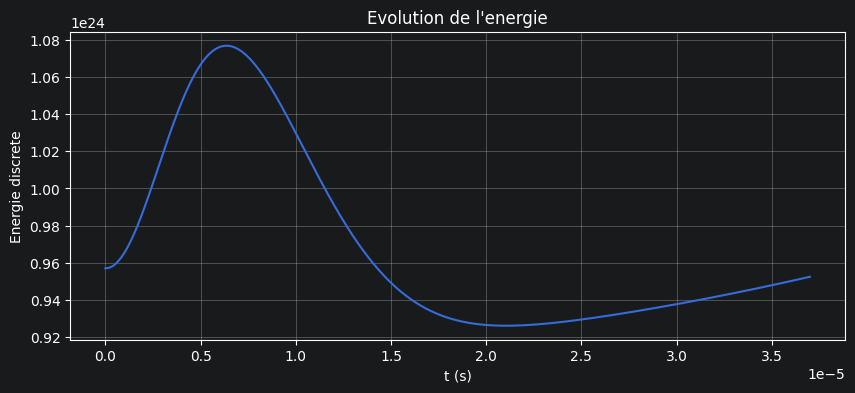

In [5]:
solver.plot_energy()


## Mini étude de stabilité

On balaye quelques valeurs de $\Delta t$ autour du pas de temps de référence et quelques amplitudes $A_1$ pour $u_0$. L'amplitude de vitesse $A_2$ est gardée égale à $-10^{11}$ comme dans le test de référence.


Indicateurs: CFL=0.13875, lambda=2.08125e+06 (legacy)
Marge de stabilité explicite: 9.80748e-09
Stable (marge positive)
Indicateurs: CFL=0.13875, lambda=2.08125e+06 (legacy)
Marge de stabilité explicite: 9.80748e-09
Stable (marge positive)
Indicateurs: CFL=0.13875, lambda=2.08125e+06 (legacy)
Marge de stabilité explicite: 9.80748e-09
Stable (marge positive)
Indicateurs: CFL=0.13875, lambda=2.08125e+06 (legacy)
Marge de stabilité explicite: 9.80748e-09
Stable (marge positive)
Indicateurs: CFL=0.13875, lambda=2.08125e+06 (legacy)
Marge de stabilité explicite: 9.80748e-09
Stable (marge positive)
Indicateurs: CFL=0.2775, lambda=4.1625e+06 (legacy)
Marge de stabilité explicite: 9.22994e-09
Stable (marge positive)
Indicateurs: CFL=0.2775, lambda=4.1625e+06 (legacy)
Marge de stabilité explicite: 9.22994e-09
Stable (marge positive)
Indicateurs: CFL=0.2775, lambda=4.1625e+06 (legacy)
Marge de stabilité explicite: 9.22994e-09
Stable (marge positive)
Indicateurs: CFL=0.2775, lambda=4.1625e+06 (le

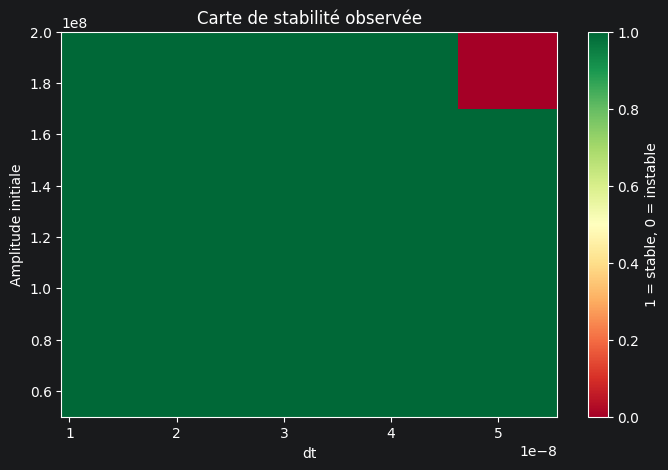

In [6]:
dt_ref = T_final / nt

dt_values = [0.5 * dt_ref, dt_ref, 1.5 * dt_ref, 2.0 * dt_ref, 3.0 * dt_ref]
amp_values = [0.5e8, 0.8e8, 1.2e8, 1.6e8, 2.0e8]

stability = solver.run_stability_scan(
    dt_values=dt_values,
    amplitude_values=amp_values,
    u0_type="gaussian",
    u1_type="gaussian_derivative",
    velocity_amplitude=1.0e11,
    mu=0.1,
    sigma1=0.015,
    sigma2=0.02,
    blowup_threshold=1e10,
)

stable_count = sum(1 for r in stability if r["stable"])
print(f"Configurations stables: {stable_count}/{len(stability)}")
plot_stability_scan(stability)


## Notes

- Pour comparer les deux schémas, changer `scheme="semi_implicit"` en `scheme="explicit"`.
- Le test de stabilité peut être coûteux avec `nx=2001` et `nt=2000`. Pour un balayage rapide, diminuer temporairement `nx` ou `nt`.
- La condition de non-dégénérescence est surveillée via `min_denom = min(1 - 2ku)`.
- Avec la convention du code $k=\beta/(\rho_0 c^2)$, la borne $1/(2k)$ vaut environ $3.21 \times 10^8$ Pa pour les paramètres ci-dessus.
